# Eq. 65–68 — The Jurisprudential Boomerang: 2A Case Law as Target Expansion (1911–2024)

**Equations:**
- **eq:65** $L_E \gg L_O \implies \text{Extraction feasible}$ — Extraction precondition
- **eq:66** $x_0 \rightarrow x_1 \rightarrow \cdots \rightarrow x_m$ — Disarmament agenda path
- **eq:67** $\mathcal{R}_{t+1} = \mathcal{R}_t \cup \{r_t\}$ — Restriction precedent accumulation
- **eq:68** $\operatorname{Target}(r_t): O_{\text{racialized}} \;\rightarrow\; O_{\text{racialized}} \cup I_{\text{buffer}}$ — Target scope expansion

## Analytical Precision — Three Event Types

| Event class | Direction | Examples | Net delta |
|---|---|---|---|
| Legislation (Congress) | Adds restriction | NFA, GCA, Hughes, Brady, AWB | +1 |
| Legislation — sunset | Removes restriction | AWB lapse (2004) | −1 |
| ATF admin rule | Adds restriction | Bump stock ban, Ghost gun rule, Pistol brace rule | +1 |
| SCOTUS — expands rights | Removes restriction | Heller, McDonald, Bruen, Cargill | −1 |
| SCOTUS — upholds restriction | Upholds restriction | Rahimi | +1 |

## Key Calibration Notes

**ATF Administrative Rules (the 'felony overnight' mechanism):** The bump stock ban (2018),
ghost gun/frame-receiver rule (2022), and pistol brace rule (2023) are ATF administrative
actions that instantly reclassified previously legal property and behavior as federal felonies
for millions of $I_{\text{buffer}}$ gun owners — without any Act of Congress. The pistol brace
rule alone affected an estimated 10–40 million braced pistols. These ATF rules are the
clearest modern examples of the boomerang mechanism: the regulatory apparatus built to manage
$O_{\text{racialized}}$ (the NFA's administrative framework) expanded to instantly criminalize
$I_{\text{buffer}}$ members who had been lawfully compliant the day before.

**Rahimi (2024) — A Quarter Step, Not an Overturn:** *United States v. Rahimi* (8-1) does NOT
overturn or modify *Bruen*. Chief Justice Roberts's majority explicitly reaffirms the
Bruen historical-tradition test and clarifies that it requires a 'relevantly similar'
historical analogue, not an identical twin. Multiple law review analyses (Harvard JLPP 2024:
'Much Ado About Nothing'; Va. L. Rev. 2024; Harvard L. Rev. 2024) characterize *Rahimi*
as reinforcing *Bruen*, not limiting it. The holding is narrow: persons adjudicated by a court
as posing a 'credible threat to physical safety' may be temporarily disarmed. Crucially,
Justice Thomas — the author of *Bruen* — was the LONE DISSENTER, arguing even this narrow
restriction lacks historical support. *Rahimi* is a one-quarter step, not a reversal.

**Bruen / Thomas and the Anti-Racist Historical Record:** Justice Thomas's *Bruen* majority
opinion explicitly cited the Sullivan Law (1911) and similar laws as examples of historically
racially targeted gun restrictions that the historical-tradition test should guard against.
This is a rare anti-racist application of the historical-tradition framework — and it shows
the boomerang's complexity: the same doctrine that calls out racial targeting can also be
extended (by others) to uphold restrictions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
from pathlib import Path

try:
    _here = Path(__file__).resolve().parent
except NameError:
    _cwd = Path.cwd()
    if (_cwd / 'data').exists():
        _here = _cwd
    elif (_cwd / 'Paper' / 'data').exists():
        _here = _cwd / 'Paper' / 'scripts'
    else:
        _here = _cwd

data_path = str(_here / '..' / 'data' / 'eq65_68_2a_case_law.csv')
df = pd.read_csv(data_path, comment='#')

# ── Assertions ──────────────────────────────────────────────────────────────────
assert df.shape[0] >= 16, f"Expected at least 16 rows, got {df.shape[0]}"
assert set(['year', 'event', 'event_class', 'jurisdiction', 'ruling_direction',
            'initial_target', 'net_restriction_delta', 'federal_legislation_cumulative',
            'net_restriction_cumulative', 'target_expansion_flag']).issubset(df.columns)

# Federal legislation count must be non-negative and non-decreasing for adds, decreasing for removes
assert (df['federal_legislation_cumulative'] >= 0).all()

# Net cumulative must match sum of deltas
recomputed = df['net_restriction_delta'].cumsum()
assert (recomputed.values == df['net_restriction_cumulative'].values).all(), \
    f"net_restriction_cumulative mismatch: {list(zip(recomputed.values, df['net_restriction_cumulative'].values))}"

assert set(df['event_class'].unique()).issubset({'legislation', 'atf_admin_rule', 'scotus_ruling'})
assert set(df['ruling_direction'].unique()).issubset(
    {'adds_restriction', 'removes_restriction', 'expands_rights', 'upholds_restriction'})

print(f"Data loaded: {df.shape[0]} rows × {df.shape[1]} columns")
cols = ['year', 'event', 'event_class', 'ruling_direction',
        'net_restriction_delta', 'federal_legislation_cumulative', 'net_restriction_cumulative']
print(df[cols].to_string(index=False))

Data loaded: 16 rows × 13 columns
 year             event    event_class    ruling_direction  net_restriction_delta  federal_legislation_cumulative  net_restriction_cumulative
 1911      Sullivan_Law    legislation    adds_restriction                      1                               0                           1
 1934               NFA    legislation    adds_restriction                      1                               1                           2
 1967       Mulford_Act    legislation    adds_restriction                      1                               1                           3
 1968               GCA    legislation    adds_restriction                      1                               2                           4
 1986  Hughes_Amendment    legislation    adds_restriction                      1                               3                           5
 1993         Brady_Act    legislation    adds_restriction                      1                               4 

In [2]:
# ── Eq:65 — Lethal Asymmetry Ratio proxy ────────────────────────────────────────
# L_E includes military + law-enforcement capacity, which SCOTUS rulings do NOT reduce.
# ATF admin rules and legislation affect civilian L_O capacity (downward = more restricted).
eras = {
    'Pre-NFA (pre-1934)':         {'fed_leg': 0, 'L_E_proxy': 1.2},
    'Post-NFA (1934–1967)':       {'fed_leg': 1, 'L_E_proxy': 2.0},
    'Post-GCA (1968–1985)':       {'fed_leg': 2, 'L_E_proxy': 2.8},
    'Post-Hughes (1986–1992)':    {'fed_leg': 3, 'L_E_proxy': 3.4},
    'Post-AWB (1994–2003)':       {'fed_leg': 5, 'L_E_proxy': 4.0},
    'Post-AWB Lapse (2004–2017)': {'fed_leg': 4, 'L_E_proxy': 3.8},
    'Post-Bump Ban (2018–2021)':  {'fed_leg': 4, 'L_E_proxy': 4.1},
    'Post-Bruen / ATF rules (2022–present)': {'fed_leg': 4, 'L_E_proxy': 4.5},
}
print("Eq:65 — Lethal Asymmetry Ratio (L_E/L_O proxy) by era:")
print(f"{'Era':<42} {'Fed Acts':>9} {'L_E/L_O':>8}")
print("-" * 63)
for era, vals in eras.items():
    print(f"{era:<42} {vals['fed_leg']:>9} {vals['L_E_proxy']:>8.1f}")
print()
print("Note: SCOTUS rulings (Heller/McDonald/Bruen) reduce civilian regulatory burden but")
print("do not reduce L_E (state lethal capacity). ATF admin rules expand the regulatory")
print("apparatus without requiring congressional action.")

# ── Eq:66 — Agenda path ─────────────────────────────────────────────────────────
print("\nEq:66 — Full Agenda Path x_0 → x_m:")
print("  " + ' → '.join(df['event'].values))
print(f"  {len(df)} events spanning {df['year'].max() - df['year'].min()} years")

Eq:65 — Lethal Asymmetry Ratio (L_E/L_O proxy) by era:
Era                                         Fed Acts  L_E/L_O
---------------------------------------------------------------
Pre-NFA (pre-1934)                                 0      1.2
Post-NFA (1934–1967)                               1      2.0
Post-GCA (1968–1985)                               2      2.8
Post-Hughes (1986–1992)                            3      3.4
Post-AWB (1994–2003)                               5      4.0
Post-AWB Lapse (2004–2017)                         4      3.8
Post-Bump Ban (2018–2021)                          4      4.1
Post-Bruen / ATF rules (2022–present)              4      4.5

Note: SCOTUS rulings (Heller/McDonald/Bruen) reduce civilian regulatory burden but
do not reduce L_E (state lethal capacity). ATF admin rules expand the regulatory
apparatus without requiring congressional action.

Eq:66 — Full Agenda Path x_0 → x_m:
  Sullivan_Law → NFA → Mulford_Act → GCA → Hughes_Amendment → Brady_Act

In [3]:
# ── Eq:67 — Restriction accumulation (two tracks) ───────────────────────────────
# Track 1: Federal Acts of Congress only (slow, requires legislative action)
# Track 2: Net restriction count (all events — shows the full two-directional arc)

years = df['year'].values
fed_leg = df['federal_legislation_cumulative'].values
net_R   = df['net_restriction_cumulative'].values

adds   = df[df['ruling_direction'] == 'adds_restriction']
atf    = df[df['event_class'] == 'atf_admin_rule']
expands= df[df['ruling_direction'].isin(['expands_rights', 'removes_restriction'])]
upholds= df[df['ruling_direction'] == 'upholds_restriction']

print("Federal legislation (Acts of Congress) — slow, constitutionally durable:")
for _, r in df[df['event_class'] == 'legislation'].iterrows():
    print(f"  {r['year']} {r['event']:<22} ({r['ruling_direction']:>20}): "
          f"fed_leg={r['federal_legislation_cumulative']}, net={r['net_restriction_cumulative']}")

print("\nATF Administrative Rules — fast, executive, felony-overnight mechanism:")
for _, r in atf.iterrows():
    status = str(r['scope_current_or_status'])[:80]
    print(f"  {r['year']} {r['event']:<25}: net_delta={r['net_restriction_delta']:+d}")
    print(f"    Scope: {status}")
    print(f"    Note: {str(r['notes'])[:100]}")

print("\nSCOTUS Rights-Expanding Rulings (net_R decreases):")
for _, r in expands.iterrows():
    print(f"  {r['year']} {r['event']:<15}: net_delta={r['net_restriction_delta']:+d}, "
          f"net_R after={r['net_restriction_cumulative']}")

print("\nSCOTUS Upholds Restriction — Rahimi:")
for _, r in upholds.iterrows():
    print(f"  {r['year']} {r['event']:<12}: net_delta={r['net_restriction_delta']:+d}, net_R={r['net_restriction_cumulative']}")
    print(f"  PRECISION: Does NOT overturn Bruen. Thomas (Bruen author) SOLE DISSENTER.")
    print(f"  Holding: narrow — adjudicated-dangerous-person-with-DV-order only.")
    print(f"  Characterization: ~1/4 step; multiple law reviews call it 'Much Ado About Nothing.'")

print(f"\nNet restriction count trajectory:")
for _, r in df.iterrows():
    marker = '↑' if r['net_restriction_delta'] > 0 else '↓'
    print(f"  {r['year']} {r['event']:<25} {marker} → net={r['net_restriction_cumulative']}")

Federal legislation (Acts of Congress) — slow, constitutionally durable:
  1911 Sullivan_Law           (    adds_restriction): fed_leg=0, net=1
  1934 NFA                    (    adds_restriction): fed_leg=1, net=2
  1967 Mulford_Act            (    adds_restriction): fed_leg=1, net=3
  1968 GCA                    (    adds_restriction): fed_leg=2, net=4
  1986 Hughes_Amendment       (    adds_restriction): fed_leg=3, net=5
  1993 Brady_Act              (    adds_restriction): fed_leg=4, net=6
  1994 AWB                    (    adds_restriction): fed_leg=5, net=7
  2004 AWB_Lapse              ( removes_restriction): fed_leg=4, net=6

ATF Administrative Rules — fast, executive, felony-overnight mechanism:
  2018 Bump_Stock_Ban           : net_delta=+1
    Scope: All bump stock owners required to destroy or surrender devices; possession = fed
    Note: ~500k devices affected overnight; later struck down by Cargill (2024)
  2022 Ghost_Gun_Rule           : net_delta=+1
    Scope: 80% lower

In [4]:
# ── Eq:68 — Target scope analysis ───────────────────────────────────────────────
restriction_events = df[df['ruling_direction'].isin(['adds_restriction', 'upholds_restriction'])]
racialized = (restriction_events['initial_target'] == 'O_racialized').sum()
joint      = (restriction_events['initial_target'] == 'O_racialized+I_buffer').sum()
buffer     = (restriction_events['initial_target'] == 'I_buffer').sum()
expansion  = restriction_events['target_expansion_flag'].sum()
exp_pct    = expansion / len(restriction_events) * 100

inflection = df[df['initial_target'] == 'I_buffer'].sort_values('year').iloc[0]

print("Eq:68 — Target Scope Expansion (restriction-adding events only):")
print(f"  O_racialized initial targeting: {racialized} (Sullivan Law, NFA, Mulford Act)")
print(f"  O_racialized+I_buffer joint:    {joint} (GCA 1968)")
print(f"  I_buffer primary:               {buffer}")
print(f"  Scope expansion to I_buffer:    {expansion}/{len(restriction_events)} ({exp_pct:.0f}%)")
print(f"  Inflection point: {inflection['year']} ({inflection['event']})")
print()
print("The ATF Admin Rule pattern (2018, 2022, 2023):")
for _, r in atf.iterrows():
    print(f"  {r['year']} {r['event']}: felony-overnight mechanism — {str(r['notes'])[:90]}")
print()
print("The three-phase boomerang arc:")
print("  Phase 1 (1911–1994): Racial targeting → doctrine accumulates → scope expands to I_buffer")
print("  Phase 2 (2004–2022): I_buffer wins rights via AWB lapse, Heller/McDonald/Bruen")
print("                        but NFA/GCA/Hughes/Brady remain fully in effect")
print("  Phase 3 (2018–2024): ATF admin rules BYPASS Congress to turn I_buffer owners into")
print("                        felons overnight (bump stocks, ghost guns, pistol braces)")
print("                        Rahimi: a narrow quarter-step uphold; Bruen framework intact")

Eq:68 — Target Scope Expansion (restriction-adding events only):
  O_racialized initial targeting: 3 (Sullivan Law, NFA, Mulford Act)
  O_racialized+I_buffer joint:    1 (GCA 1968)
  I_buffer primary:               7
  Scope expansion to I_buffer:    10/11 (91%)
  Inflection point: 1986 (Hughes_Amendment)

The ATF Admin Rule pattern (2018, 2022, 2023):
  2018 Bump_Stock_Ban: felony-overnight mechanism — ~500k devices affected overnight; later struck down by Cargill (2024)
  2022 Ghost_Gun_Rule: felony-overnight mechanism — Millions of parts overnight reclassified; VanDerStok (2024) upheld the rule 7-2
  2023 Pistol_Brace_Rule: felony-overnight mechanism — Vacated by federal courts; DOJ dropped appeal July 2025; included here as point-in-time re

The three-phase boomerang arc:
  Phase 1 (1911–1994): Racial targeting → doctrine accumulates → scope expands to I_buffer
  Phase 2 (2004–2022): I_buffer wins rights via AWB lapse, Heller/McDonald/Bruen
                        but NFA/GCA/Hughe

In [5]:
# ── Shared color palette ────────────────────────────────────────────────────────
figures_dir = _here / '..' / 'figures'
os.makedirs(str(figures_dir), exist_ok=True)

COLOR_FED_LEG  = '#8B1A1A'   # federal legislation (dark red)
COLOR_STATE    = '#C07000'   # state legislation (amber)
COLOR_ATF      = '#9B4A00'   # ATF admin rules (burnt orange)
COLOR_RIGHTS   = '#2E7B2E'   # rights-expanding SCOTUS (green)
COLOR_UPHOLD   = '#4A2E7B'   # rights-upholding / Rahimi (purple)
COLOR_REMOVE   = '#1A7B4A'   # sunset / court vacation (teal)
COLOR_NET_LINE = '#333333'

def event_color(row):
    rd, ec = row['ruling_direction'], row['event_class']
    if ec == 'legislation' and row['jurisdiction'] == 'state': return COLOR_STATE
    if rd == 'removes_restriction': return COLOR_REMOVE
    if ec == 'legislation': return COLOR_FED_LEG
    if ec == 'atf_admin_rule': return COLOR_ATF
    if rd == 'expands_rights': return COLOR_RIGHTS
    if rd == 'upholds_restriction': return COLOR_UPHOLD
    return COLOR_NET_LINE

def event_marker(row):
    rd, ec = row['ruling_direction'], row['event_class']
    if ec == 'legislation' and row['jurisdiction'] == 'state': return 'D'
    if ec == 'atf_admin_rule': return 's'
    if rd == 'expands_rights': return '^'
    if rd == 'removes_restriction': return 'v'
    if rd == 'upholds_restriction': return 'P'
    return 'o'

print("Color palette and helpers defined.")

Color palette and helpers defined.


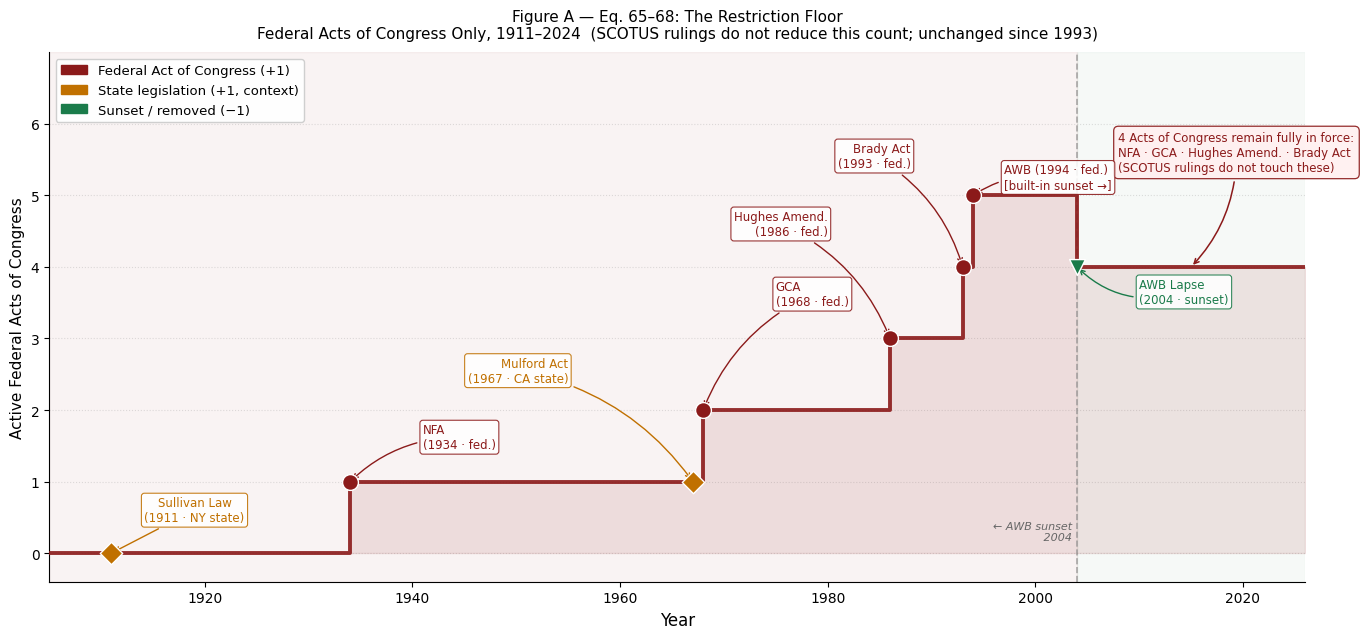

Figure A saved → /Users/emmanuel/Documents/Theory/Redefining_racism/Paper/scripts/../figures/eq65_68_fig_a_legislation.png


In [6]:
# ── Figure A: Federal Acts of Congress — the durable restriction floor ──────────
fig_a, ax = plt.subplots(figsize=(14, 6.5))

leg_df = df[df['event_class'] == 'legislation'].copy()

# Build step series (federal legislation count — holds between legislation events)
xs = [1905] + list(df['year'].values) + [2026]
fed_vals = [0]
cur = 0
for _, row in df.iterrows():
    if row['event_class'] == 'legislation':
        cur = row['federal_legislation_cumulative']
    fed_vals.append(cur)
fed_vals.append(cur)

# Light era shading
ax.axvspan(1905, 2004, alpha=0.05, color='#8B1A1A')
ax.axvspan(2004, 2026, alpha=0.04, color='#1A7B4A')

ax.step(xs, fed_vals, where='post', color=COLOR_FED_LEG, linewidth=2.8, alpha=0.9, zorder=3)
ax.fill_between(xs, fed_vals, step='post', alpha=0.10, color=COLOR_FED_LEG, zorder=2)

# AWB sunset dashed line
ax.axvline(x=2004, color='#888888', linestyle='--', linewidth=1.2, alpha=0.7)
ax.text(2003.5, 0.15, '← AWB sunset\n   2004', fontsize=8, color='#666666',
        ha='right', va='bottom', style='italic')

# Flat-floor label (post-2004 period)
ax.annotate(
    '4 Acts of Congress remain fully in force:\nNFA · GCA · Hughes Amend. · Brady Act\n'
    '(SCOTUS rulings do not touch these)',
    xy=(2015, 4.0), xytext=(2008, 5.6),
    arrowprops=dict(arrowstyle='->', color=COLOR_FED_LEG, lw=1.1,
                    connectionstyle='arc3,rad=-0.2'),
    fontsize=8.5, color=COLOR_FED_LEG, ha='left', va='center',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF0F0',
              edgecolor=COLOR_FED_LEG, alpha=0.92, linewidth=0.9)
)

# ── Per-event markers and annotations ─────────────────────────────────────────
# (x_text, y_text, ha, connection_rad)
ANNOTS_A = {
    'Sullivan_Law':     (1919, 0.60, 'center',  0.0),
    'NFA':              (1941, 1.62, 'left',    0.2),
    'Mulford_Act':      (1955, 2.55, 'right',  -0.2),
    'GCA':              (1975, 3.62, 'left',    0.2),
    'Hughes_Amendment': (1980, 4.60, 'right',  -0.2),
    'Brady_Act':        (1988, 5.55, 'right',  -0.2),
    'AWB':              (1997, 5.25, 'left',    0.2),
    'AWB_Lapse':        (2010, 3.65, 'left',   -0.3),
}
LABELS_A = {
    'Sullivan_Law':     'Sullivan Law\n(1911 · NY state)',
    'NFA':              'NFA\n(1934 · fed.)',
    'Mulford_Act':      'Mulford Act\n(1967 · CA state)',
    'GCA':              'GCA\n(1968 · fed.)',
    'Hughes_Amendment': 'Hughes Amend.\n(1986 · fed.)',
    'Brady_Act':        'Brady Act\n(1993 · fed.)',
    'AWB':              'AWB (1994 · fed.)\n[built-in sunset →]',
    'AWB_Lapse':        'AWB Lapse\n(2004 · sunset)',
}

for _, row in leg_df.iterrows():
    ev    = row['event']
    color = COLOR_REMOVE if row['ruling_direction'] == 'removes_restriction' else \
            COLOR_STATE  if row['jurisdiction'] == 'state' else COLOR_FED_LEG
    mkr   = 'v' if row['ruling_direction'] == 'removes_restriction' else \
            'D' if row['jurisdiction'] == 'state' else 'o'
    y_val = row['federal_legislation_cumulative']
    ax.scatter(row['year'], y_val, color=color, s=130, zorder=7,
               marker=mkr, edgecolors='white', linewidth=1.0)
    if ev in ANNOTS_A:
        xt, yt, ha, rad = ANNOTS_A[ev]
        ax.annotate(
            LABELS_A[ev],
            xy=(row['year'], y_val),
            xytext=(xt, yt),
            arrowprops=dict(arrowstyle='->', color=color, lw=1.0,
                            connectionstyle=f'arc3,rad={rad}'),
            fontsize=8.5, color=color, ha=ha, va='center',
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                      edgecolor=color, alpha=0.88, linewidth=0.8)
        )

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Active Federal Acts of Congress', fontsize=11)
ax.set_xlim(1905, 2026)
ax.set_ylim(-0.4, 7.0)
ax.set_yticks(range(0, 7))
ax.set_title(
    'Figure A — Eq. 65–68: The Restriction Floor\n'
    'Federal Acts of Congress Only, 1911–2024  '
    '(SCOTUS rulings do not reduce this count; unchanged since 1993)',
    fontsize=11, pad=10)
ax.legend(handles=[
    mpatches.Patch(color=COLOR_FED_LEG, label='Federal Act of Congress (+1)'),
    mpatches.Patch(color=COLOR_STATE,   label='State legislation (+1, context)'),
    mpatches.Patch(color=COLOR_REMOVE,  label='Sunset / removed (−1)'),
], fontsize=9.5, loc='upper left', framealpha=0.92)
ax.grid(axis='y', linestyle=':', alpha=0.30, color='#999999')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
fig_a_path = str(figures_dir / 'eq65_68_fig_a_legislation.png')
plt.savefig(fig_a_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure A saved → {fig_a_path}")

/var/folders/95/ps3stnmx59j3ws19bprd4h9r0000gn/T/ipykernel_33573/4163125723.py:220: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


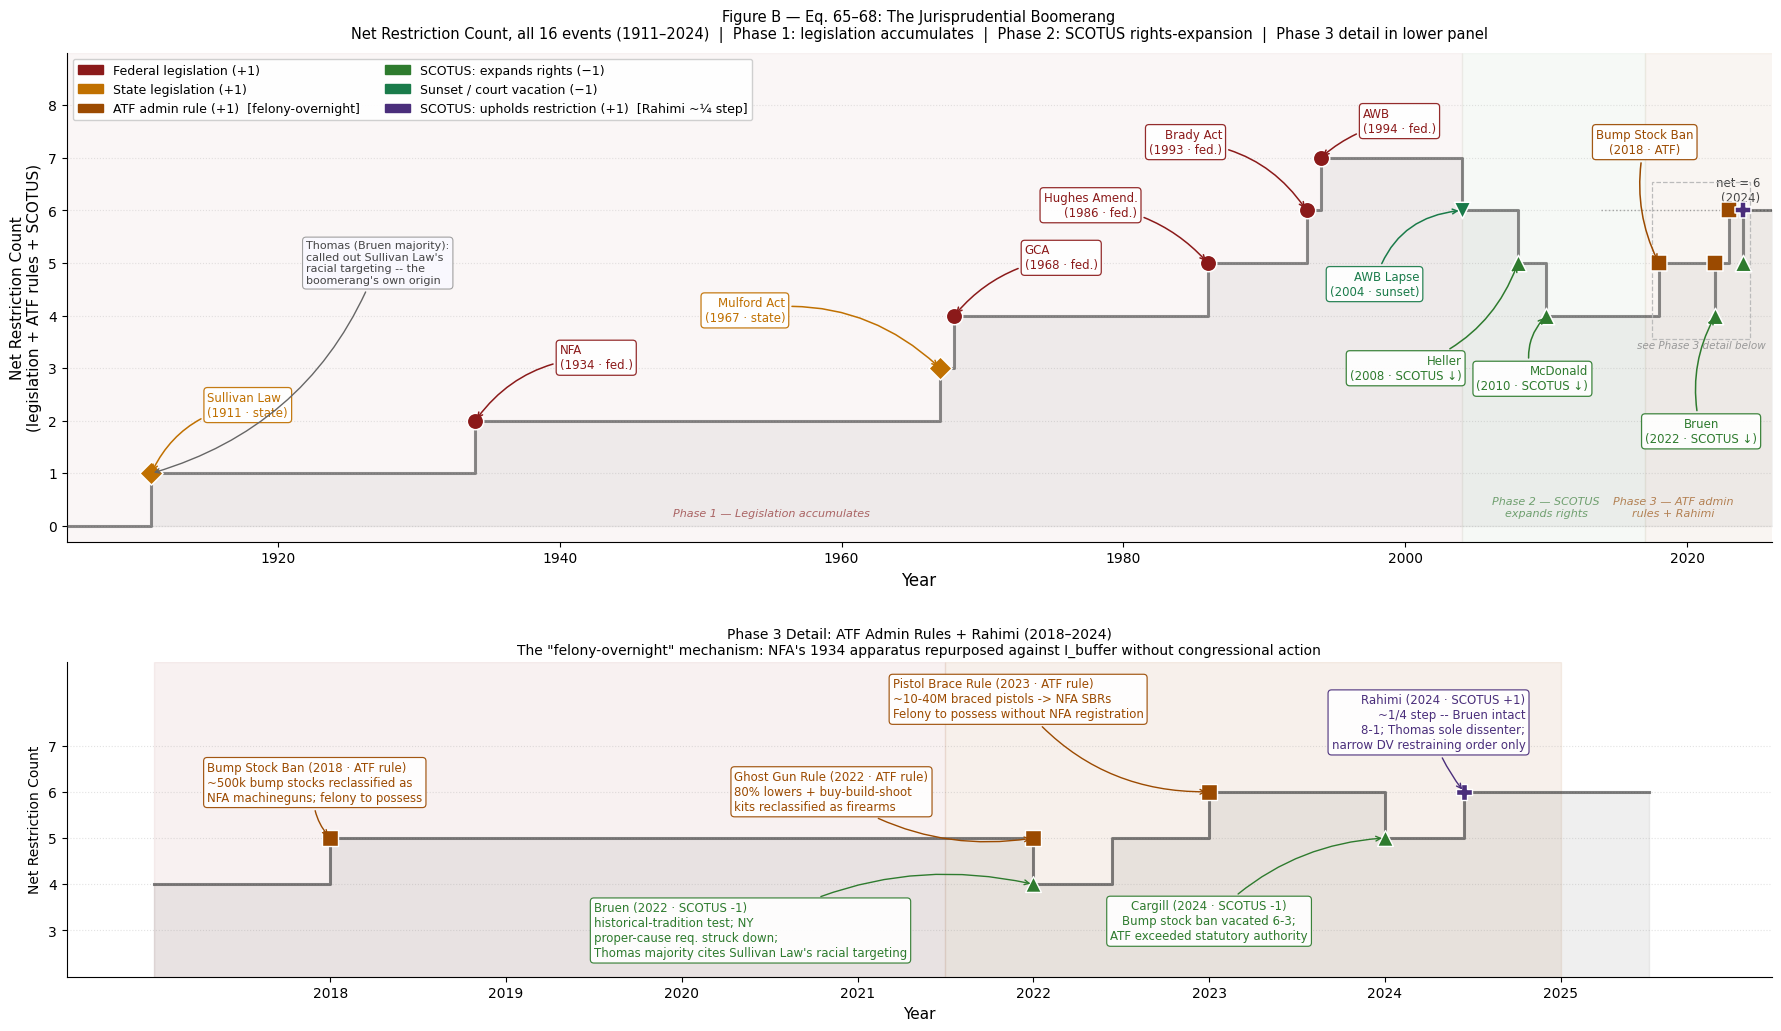

Figure B saved → /Users/emmanuel/Documents/Theory/Redefining_racism/Paper/scripts/../figures/eq65_68_fig_b_net_restriction.png


In [7]:
# ── Figure B: Net Restriction Count — two-row layout ─────────────────────────
# Row 1 (top): full 16-event arc (1905-2024); Phase 3 markers labeled minimally
# Row 2 (bottom): Phase 3 detail panel (2017-2025) with full annotations
fig_b, (ax, ax2) = plt.subplots(
    2, 1, figsize=(22, 12),
    gridspec_kw={'height_ratios': [2.8, 1.8], 'hspace': 0.30}
)

# ── Era shading ────────────────────────────────────────────────────────────────
ax.axvspan(1905, 2004, alpha=0.04, color='#8B1A1A', zorder=1)
ax.axvspan(2004, 2017, alpha=0.04, color='#2E7B2E', zorder=1)
ax.axvspan(2017, 2027, alpha=0.05, color='#9B4A00', zorder=1)

# Phase labels — centered in each band, low enough to not crowd annotations
for xc, lbl, col in [
    (1955, 'Phase 1 — Legislation accumulates', '#8B1A1A'),
    (2010, 'Phase 2 — SCOTUS\nexpands rights', '#2E7B2E'),
    (2019, 'Phase 3 — ATF admin\nrules + Rahimi', '#9B4A00'),
]:
    ax.text(xc, 0.15, lbl, fontsize=8, color=col, ha='center', va='bottom',
            alpha=0.65, style='italic')

# ── Step line ──────────────────────────────────────────────────────────────────
xs_b  = [1905] + list(df['year'].values) + [2027]
net_s = [0] + list(df['net_restriction_cumulative'].values) + \
        [df['net_restriction_cumulative'].iloc[-1]]

ax.step(xs_b, net_s, where='post', color=COLOR_NET_LINE,
        linewidth=2.2, alpha=0.55, zorder=4)
ax.fill_between(xs_b, net_s, step='post', alpha=0.06,
                color=COLOR_NET_LINE, zorder=3)

# ── Annotation map — manually placed to avoid all overlap ─────────────────────
# Each entry: event_name → (x_text, y_text, ha, arc_rad)
# Positive arc_rad = curve right; negative = curve left.
# "above" annotations: y_text > data point  |  "below": y_text < data point
ANNOTS_B = {
    # ── Phase 1: legislation ──────────────────────────────────────────────────
    'Sullivan_Law':     (1915,  2.3, 'left',    0.28),   # net=1 — above-right of data pt
    'NFA':              (1940,  3.2, 'left',    0.25),   # net=2
    'Mulford_Act':      (1956,  4.1, 'right',  -0.25),   # net=3
    'GCA':              (1973,  5.1, 'left',    0.20),   # net=4
    'Hughes_Amendment': (1981,  6.1, 'right',  -0.20),   # net=5
    'Brady_Act':        (1987,  7.3, 'right',  -0.25),   # net=6
    'AWB':              (1997,  7.7, 'left',    0.15),   # net=7
    # ── Phase 2: AWB lapse + SCOTUS ───────────────────────────────────────────
    'AWB_Lapse':        (2001,  4.6, 'right',  -0.35),   # net=6, below the peak
    'Heller':           (2004,  3.0, 'right',   0.25),   # net=5 — label LEFT of data pt
    'McDonald':         (2013,  2.8, 'right',  -0.30),   # net=4
    # Phase 3 events (Bump_Stock_Ban onward) get a short label only —
    # detailed annotations handled in the inset zoom panel below.
        'Bump_Stock_Ban':   (2017,  7.3, 'center',  0.18),
    'Bruen':            (2021,  1.8, 'center', -0.20),
    # Ghost_Gun_Rule, Pistol_Brace_Rule, Cargill, Rahimi: INSET ONLY, skip inline
}
LABELS_B = {
    'Sullivan_Law':      'Sullivan Law\n(1911 · state)',
    'NFA':               'NFA\n(1934 · fed.)',
    'Mulford_Act':       'Mulford Act\n(1967 · state)',
    'GCA':               'GCA\n(1968 · fed.)',
    'Hughes_Amendment':  'Hughes Amend.\n(1986 · fed.)',
    'Brady_Act':         'Brady Act\n(1993 · fed.)',
    'AWB':               'AWB\n(1994 · fed.)',
    'AWB_Lapse':         'AWB Lapse\n(2004 · sunset)',
    'Heller':            'Heller\n(2008 · SCOTUS ↓)',
    'McDonald':          'McDonald\n(2010 · SCOTUS ↓)',
    'Bump_Stock_Ban':    'Bump Stock Ban\n(2018 · ATF)',
    'Bruen':             'Bruen\n(2022 · SCOTUS ↓)',
    # Phase 3 short labels for inset only:
    'Ghost_Gun_Rule':    'Ghost Gun Rule\n(2022 · ATF)',
    'Pistol_Brace_Rule': 'Pistol Brace\n(2023 · ATF)',
    'Cargill':           'Cargill\n(2024 · SCOTUS ↓)',
    'Rahimi':            'Rahimi\n(2024 · SCOTUS)',
}

for _, row in df.iterrows():
    ev    = row['event']
    color = event_color(row)
    mkr   = event_marker(row)
    y_val = row['net_restriction_cumulative']
    yr    = row['year']

    ax.scatter(yr, y_val, color=color, s=140, zorder=8,
               marker=mkr, edgecolors='white', linewidth=1.1)

    if ev in ANNOTS_B:
        xt, yt, ha, rad = ANNOTS_B[ev]
        ax.annotate(
            LABELS_B.get(ev, ev),
            xy=(yr, y_val),
            xytext=(xt, yt),
            arrowprops=dict(arrowstyle='->', color=color, lw=1.1,
                            connectionstyle=f'arc3,rad={rad}'),
            fontsize=8.5, color=color, ha=ha, va='center',
            bbox=dict(boxstyle='round,pad=0.30', facecolor='white',
                      edgecolor=color, alpha=0.92, linewidth=0.9),
            zorder=10
        )

# ── Thomas / Bruen anti-racist callout on main axis ──────────────────────────
ax.annotate(
    "Thomas (Bruen majority):\ncalled out Sullivan Law's\nracial targeting -- the\nboomerang's own origin",
    xy=(1911, 1.0), xytext=(1922, 5.0),
    arrowprops=dict(arrowstyle='->', color='#666666', lw=1.0,
                    connectionstyle='arc3,rad=-0.25'),
    fontsize=8, color='#444444', ha='left', va='center',
    bbox=dict(boxstyle='round,pad=0.32', facecolor='#F9F9FF',
              edgecolor='#999999', alpha=0.92, linewidth=0.8),
    zorder=10
)

# ── Terminal net=6 line ────────────────────────────────────────────────────────
ax.axhline(y=6, xmin=0.90, xmax=1.0, color='#666666',
           linestyle=':', linewidth=1.0, alpha=0.55)
ax.text(2025.2, 6.12, 'net = 6\n(2024)', fontsize=8.5, color='#444444',
        ha='right', va='bottom')

# Main axis labels / limits
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Net Restriction Count\n(legislation + ATF rules + SCOTUS)', fontsize=11)
ax.set_xlim(1905, 2026)
ax.set_ylim(-0.3, 9.0)
ax.set_yticks(range(0, 9))
ax.set_title(
    'Figure B — Eq. 65–68: The Jurisprudential Boomerang\n'
    'Net Restriction Count, all 16 events (1911–2024)  '
    '|  Phase 1: legislation accumulates  '
    '|  Phase 2: SCOTUS rights-expansion  '
    '|  Phase 3 detail in lower panel',
    fontsize=10.5, pad=10)
ax.legend(handles=[
    mpatches.Patch(color=COLOR_FED_LEG, label='Federal legislation (+1)'),
    mpatches.Patch(color=COLOR_STATE,   label='State legislation (+1)'),
    mpatches.Patch(color=COLOR_ATF,     label='ATF admin rule (+1)  [felony-overnight]'),
    mpatches.Patch(color=COLOR_RIGHTS,  label='SCOTUS: expands rights (−1)'),
    mpatches.Patch(color=COLOR_REMOVE,  label='Sunset / court vacation (−1)'),
    mpatches.Patch(color=COLOR_UPHOLD,  label='SCOTUS: upholds restriction (+1)  [Rahimi ~¼ step]'),
], fontsize=9, loc='upper left', framealpha=0.93, ncol=2)
ax.grid(axis='y', linestyle=':', alpha=0.25, color='#999999')
ax.spines[['top', 'right']].set_visible(False)

# ── Row 2: Phase 3 detail panel (2017–2025) ───────────────────────────────────
ax2.axvspan(2017, 2021.5, alpha=0.06, color='#8B1A1A')
ax2.axvspan(2021.5, 2025,  alpha=0.08, color='#9B4A00')

pre_net = int(df[df['year'] < 2018].iloc[-1]['net_restriction_cumulative'])
df_p3   = df[df['year'] >= 2018].copy()

# Spread same-year events slightly so both steps are visible (e.g. Cargill dip before Rahimi).
# The markers stay at real data years; only the step-chart xs are offset.
xs_p3 = [2017]
ys_p3 = [pre_net]
_yr_count = {}
for _, row in df_p3.iterrows():
    yr = int(row['year'])
    cnt = _yr_count.get(yr, 0)
    _yr_count[yr] = cnt + 1
    xs_p3.append(yr + cnt * 0.45)          # 0.45-year gap between same-year events
    ys_p3.append(int(row['net_restriction_cumulative']))
xs_p3.append(2025.5)
ys_p3.append(int(df_p3.iloc[-1]['net_restriction_cumulative']))

ax2.step(xs_p3, ys_p3, where='post', color=COLOR_NET_LINE, linewidth=2.2, alpha=0.6)
ax2.fill_between(xs_p3, ys_p3, step='post', alpha=0.08, color=COLOR_NET_LINE)

# Phase 3 detailed annotations — full text, well-spaced
# Format: (event, data_x, data_y, label_x, label_y, ha, rad, label)
P3_ANNOTS = [
    ('Bump_Stock_Ban',    2018, 5, 2017.3, 6.2, 'left',   0.25,
     'Bump Stock Ban (2018 · ATF rule)\n~500k bump stocks reclassified as\nNFA machineguns; felony to possess'),
    ('Bruen',             2022, 4, 2019.5, 3.0, 'left',  -0.20,
     'Bruen (2022 · SCOTUS -1)\nhistorical-tradition test; NY\nproper-cause req. struck down;\nThomas majority cites Sullivan Law\'s racial targeting'),
    ('Ghost_Gun_Rule',    2022, 5, 2020.3, 6.0, 'left',   0.20,
     'Ghost Gun Rule (2022 · ATF rule)\n80% lowers + buy-build-shoot\nkits reclassified as firearms'),
    ('Pistol_Brace_Rule', 2023,   6, 2021.2, 8.0, 'left',   0.25,
     'Pistol Brace Rule (2023 · ATF rule)\n~10-40M braced pistols -> NFA SBRs\nFelony to possess without NFA registration'),
    # Cargill and Rahimi: both 2024 — markers offset 0.45 apart to match spread step
    ('Cargill',           2024,   5, 2023.0, 3.2, 'center', -0.20,
     'Cargill (2024 · SCOTUS -1)\nBump stock ban vacated 6-3;\nATF exceeded statutory authority'),
    ('Rahimi',            2024.45, 6, 2024.8, 7.5, 'right',  0.10,
     'Rahimi (2024 · SCOTUS +1)\n~1/4 step -- Bruen intact\n8-1; Thomas sole dissenter;\nnarrow DV restraining order only'),
]

for ev, xd, yd, xt, yt, ha, rad, lbl in P3_ANNOTS:
    row   = df[df['event'] == ev].iloc[0]
    color = event_color(row)
    mkr   = event_marker(row)
    ax2.scatter(xd, yd, color=color, s=130, zorder=8,
                marker=mkr, edgecolors='white', linewidth=1.0)
    ax2.annotate(
        lbl, xy=(xd, yd), xytext=(xt, yt),
        arrowprops=dict(arrowstyle='->', color=color, lw=1.0,
                        connectionstyle=f'arc3,rad={rad}'),
        fontsize=8.5, color=color, ha=ha, va='center',
        bbox=dict(boxstyle='round,pad=0.30', facecolor='white',
                  edgecolor=color, alpha=0.93, linewidth=0.85),
        zorder=10
    )

ax2.set_xlim(2016.5, 2026.2)
ax2.set_ylim(2.0, 8.8)
ax2.set_yticks([3, 4, 5, 6, 7])
ax2.set_xticks([2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025])
ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('Net Restriction Count', fontsize=10)
ax2.set_title(
    'Phase 3 Detail: ATF Admin Rules + Rahimi (2018–2024)\n'
    'The "felony-overnight" mechanism: NFA\'s 1934 apparatus repurposed against I_buffer without congressional action',
    fontsize=10, pad=6)
ax2.grid(axis='y', linestyle=':', alpha=0.28, color='#999999')
ax2.spines[['top', 'right']].set_visible(False)

# Connect top and bottom panels with a bracket marking Phase 3 on the main chart
ax.add_patch(plt.Rectangle((2017.5, 3.55), 7.0, 3.0, fill=False,
                             edgecolor='#BBBBBB', linestyle='--',
                             linewidth=0.9, zorder=5, clip_on=False))
ax.text(2021, 3.38, 'see Phase 3 detail below', fontsize=7.5,
        color='#999999', ha='center', style='italic')

plt.tight_layout()
fig_b_path = str(figures_dir / 'eq65_68_fig_b_net_restriction.png')
plt.savefig(fig_b_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure B saved → {fig_b_path}")

In [8]:
# ── Summary statistics for manuscript reference ──────────────────────────────────
print("=== Summary Statistics for Manuscript ===")
print()
print(f"Total events in dataset: {len(df)}")
print(f"Federal Acts of Congress (current active): {df['federal_legislation_cumulative'].iloc[-1]}")
print(f"Net restriction count (2024 terminal): {df['net_restriction_cumulative'].iloc[-1]}")
print()
print("ATF Admin Rule 'felony-overnight' events:")
for _, r in atf.iterrows():
    print(f"  {r['year']} {r['event']}: {str(r['notes'])[:90]}")
print()
print("Net restriction trajectory (key waypoints):")
for yr, ev in [(1994, 'AWB'), (2004, 'AWB_Lapse'), (2010, 'McDonald'),
               (2018, 'Bump_Stock_Ban'), (2022, 'Bruen'), (2024, 'Rahimi')]:
    row = df[df['event'] == ev]
    if len(row) > 0:
        print(f"  {yr} {ev:<22}: net_R = {row['net_restriction_cumulative'].values[0]}")
print()
print("Rahimi precision:")
print("  - 8-1 decision; Roberts majority REAFFIRMS Bruen test")
print("  - Thomas (Bruen author) = SOLE DISSENTER")
print("  - Narrow: only adjudicated-dangerous-person + DV restraining order")
print("  - Harvard JLPP 2024: 'Much Ado About Nothing: Rahimi Reinforces Bruen and Heller'")
print("  - Characterization: ~quarter step; Bruen fully intact")
print()
print(f"Target expansion (restriction events): {expansion}/{len(restriction_events)} ({exp_pct:.0f}%)")
print(f"Inflection point: {inflection['year']} ({inflection['event']})")

=== Summary Statistics for Manuscript ===

Total events in dataset: 16
Federal Acts of Congress (current active): 4
Net restriction count (2024 terminal): 6

ATF Admin Rule 'felony-overnight' events:
  2018 Bump_Stock_Ban: ~500k devices affected overnight; later struck down by Cargill (2024)
  2022 Ghost_Gun_Rule: Millions of parts overnight reclassified; VanDerStok (2024) upheld the rule 7-2
  2023 Pistol_Brace_Rule: Vacated by federal courts; DOJ dropped appeal July 2025; included here as point-in-time re

Net restriction trajectory (key waypoints):
  1994 AWB                   : net_R = 7
  2004 AWB_Lapse             : net_R = 6
  2010 McDonald              : net_R = 4
  2018 Bump_Stock_Ban        : net_R = 5
  2022 Bruen                 : net_R = 4
  2024 Rahimi                : net_R = 6

Rahimi precision:
  - 8-1 decision; Roberts majority REAFFIRMS Bruen test
  - Thomas (Bruen author) = SOLE DISSENTER
  - Narrow: only adjudicated-dangerous-person + DV restraining order
  - Harva

## Confound Check: "Heller/McDonald/Bruen Prove the System Self-Corrects"

**Anticipated critique (from gun-rights advocates who will scrutinize this section most closely):**
"The I_buffer won these cases. Heller, McDonald, and Bruen show the 2A works as designed.
And the ATF rules were overturned by courts — the system corrects itself. Rahimi was a narrow
DV case, not a rollback of gun rights broadly."

**The framework's precise response:**

**Methodological note on event weighting.** Each event scores +1 (restriction added or upheld)
or −1 (restriction removed or rights expanded), following eq. 67's set-union semantics:
$\mathcal{R}_{t+1} = \mathcal{R}_t \cup \{r_t\}$ counts *precedent accumulation*, not legislative
severity. A Heller is −1 and a Sullivan Law is +1 not because they are equivalent in impact,
but because they each add or remove one element from the active-precedent set. Severity and
scope are captured in the *target_expansion_flag* and the qualitative annotations; the count
measures structural trajectory, not magnitude. This is the appropriate metric for eq. 67.

**1. The federal restriction FLOOR has not moved.** Despite Heller, McDonald, and Bruen,
the NFA (1934), GCA (1968), Hughes Amendment (1986), and Brady Act (1993) all remain fully
in effect. The SCOTUS rights-expansion rulings struck specific state/local regulations;
they did not touch the federal Acts of Congress that form the restriction floor. The federal
legislation count dropped from 5 to 4 only because the AWB had a pre-written sunset clause
— Congress built the expiration in before it passed.

**2. The ATF admin rule mechanism is the boomerang's sharpest edge.** Gun-rights advocates
who focus on SCOTUS victories are looking at the wrong mechanism. The bump stock ban (2018),
ghost gun rule (2022), and pistol brace rule (2023) demonstrate that the executive branch
can bypass Congress entirely to instantly reclassify legal property as a federal felony for
millions of $I_{\text{buffer}}$ gun owners. The courts eventually vacated the bump stock and
pistol brace rules — but not before years of legal uncertainty, compliance costs, and
millions of gun owners who modified or surrendered property. The ghost gun rule survived
(*VanDerStok*, 2024, 7-2). This is the NFA's administrative apparatus — built to manage
$O_{\text{racialized}}$ in 1934 — being deployed against $I_{\text{buffer}}$ without a single
congressional vote.

**3. Justice Thomas's Bruen majority and the anti-racist historical record.** The gun-rights
advocate's best ally in calling out the boomerang is arguably Justice Thomas, who wrote the
*Bruen* majority and explicitly cited the Sullivan Law and historically racially targeted
gun laws as the reason the historical-tradition test is needed. Thomas's *Rahimi* dissent
— arguing that even the DV restraining order ban lacks historical support — reflects a
consistent application of the framework: if the historical-tradition test is to be a genuine
anti-racist tool, it must be applied strictly. The majority's willingness to stretch the
analogy in *Rahimi* is precisely what Thomas objected to.

**4. Rahimi is a quarter step, not an overturning.** The holding is narrow, 8-1, and multiple
legal scholars characterize it as reinforcing rather than limiting *Bruen*. The boomerang's
completion will not come from a single SCOTUS decision — it will come from the accumulation
of ATF rulemaking, state legislative responses to *Bruen*, and the gradual judicial expansion
of 'historical analogue' reasoning to cover an ever-wider set of restrictions on $I_{\text{buffer}}$.